Підготовка даних

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from scipy.cluster.hierarchy import linkage, dendrogram, fcluster
from scipy.spatial.distance import squareform

# завантаження даних
df = pd.read_excel('/content/data_fin.xlsx')
data = df.copy()

# додаткові індикатори
data['no_orders_flag'] = (data['orders_cnt_last_3m'] == 0).astype(int)
data['no_recent_orders_flag'] = (data['days_since_last_order'] == 2000).astype(int)

# заміна технічних значень
data['avg_days_between_orders'] = data['avg_days_between_orders'].replace(999, 0)
data['days_since_last_order'] = data['days_since_last_order'].replace(2000, 0)

# список ознак для аналізу структури
feature_cols = [
    'Contractor_Gender',
    'Age_Simple',
    'bnpl_limit',
    'orders_cnt_last_3m',
    'total_spent_last_3m',
    'avg_check_last_3m',
    'max_check_last_3m',
    'expensive_orders_share',
    'avg_days_between_orders',
    'days_since_last_order',
    'had_bnpl_before',
    'bnpl_orders_cnt_last_3m',
    'bnpl_share',
    'utilization',
    'last_order_amount',
    'last_order_was_bnpl',
    'no_orders_flag',
    'no_recent_orders_flag'
]

X_struct = data[feature_cols].copy()

print(X_struct.shape)
X_struct.head()

(30584, 18)


,Contractor_Gender,Age_Simple,bnpl_limit,orders_cnt_last_3m,total_spent_last_3m,avg_check_last_3m,max_check_last_3m,expensive_orders_share,avg_days_between_orders,days_since_last_order,had_bnpl_before,bnpl_orders_cnt_last_3m,bnpl_share,utilization,last_order_amount,last_order_was_bnpl,no_orders_flag,no_recent_orders_flag
0,0,62,30000,0,0,0.000000,0,0.000000,0.000000,0,0,0,0.000,0.0000,0,0,1,1
1,0,42,30000,1,3399,3399.000000,3399,1.000000,0.000000,5,1,1,1.000,0.1133,3399,1,0,0
2,1,41,5000,8,7787,973.375000,4699,0.125000,5.571428,11,1,7,0.875,1.3994,376,1,0,0
3,0,39,30000,6,4850,808.333333,1129,0.166667,0.000000,49,0,0,0.000,0.0000,409,0,0,0
4,1,32,10000,0,0,0.000000,0,0.000000,0.000000,0,0,0,0.000,0.0000,0,0,1,1


Кореляційна матриця

In [2]:
corr_matrix = X_struct.corr()

corr_matrix.round(3)

,Contractor_Gender,Age_Simple,bnpl_limit,orders_cnt_last_3m,total_spent_last_3m,avg_check_last_3m,max_check_last_3m,expensive_orders_share,avg_days_between_orders,days_since_last_order,had_bnpl_before,bnpl_orders_cnt_last_3m,bnpl_share,utilization,last_order_amount,last_order_was_bnpl,no_orders_flag,no_recent_orders_flag
Contractor_Gender,1.000,0.002,-0.064,-0.117,-0.067,0.045,0.006,-0.004,-0.042,0.029,-0.075,-0.075,-0.047,-0.020,0.062,-0.010,0.094,0.097
Age_Simple,0.002,1.000,0.229,0.061,0.048,0.018,0.033,0.002,0.043,-0.022,0.070,0.026,0.007,-0.028,0.017,-0.011,-0.035,-0.043
bnpl_limit,-0.064,0.229,1.000,0.024,0.023,0.028,0.026,0.019,0.069,0.014,0.122,-0.024,-0.022,-0.223,0.052,-0.002,-0.055,-0.147
orders_cnt_last_3m,-0.117,0.061,0.024,1.000,0.822,0.082,0.336,0.125,0.033,-0.293,0.198,0.519,0.151,0.350,-0.027,0.007,-0.418,-0.163
total_spent_last_3m,-0.067,0.048,0.023,0.822,1.000,0.318,0.622,0.286,0.034,-0.257,0.167,0.417,0.157,0.396,0.162,0.024,-0.376,-0.146
avg_check_last_3m,0.045,0.018,0.028,0.082,0.318,1.000,0.728,0.517,0.113,-0.199,0.063,0.064,0.201,0.145,0.715,0.045,-0.356,-0.139
max_check_last_3m,0.006,0.033,0.026,0.336,0.622,0.728,1.000,0.426,0.119,-0.249,0.114,0.173,0.178,0.252,0.511,0.028,-0.402,-0.157
expensive_orders_share,-0.004,0.002,0.019,0.125,0.286,0.517,0.426,1.000,0.194,-0.299,0.130,0.113,0.350,0.201,0.286,0.105,-0.534,-0.208
avg_days_between_orders,-0.042,0.043,0.069,0.033,0.034,0.113,0.119,0.194,1.000,-0.279,0.149,0.035,0.191,0.033,0.007,0.021,-0.421,-0.164
days_since_last_order,0.029,-0.022,0.014,-0.293,-0.257,-0.199,-0.249,-0.299,-0.279,1.000,-0.096,-0.192,-0.255,-0.158,0.034,0.043,0.581,-0.254


Heatmap кореляцій

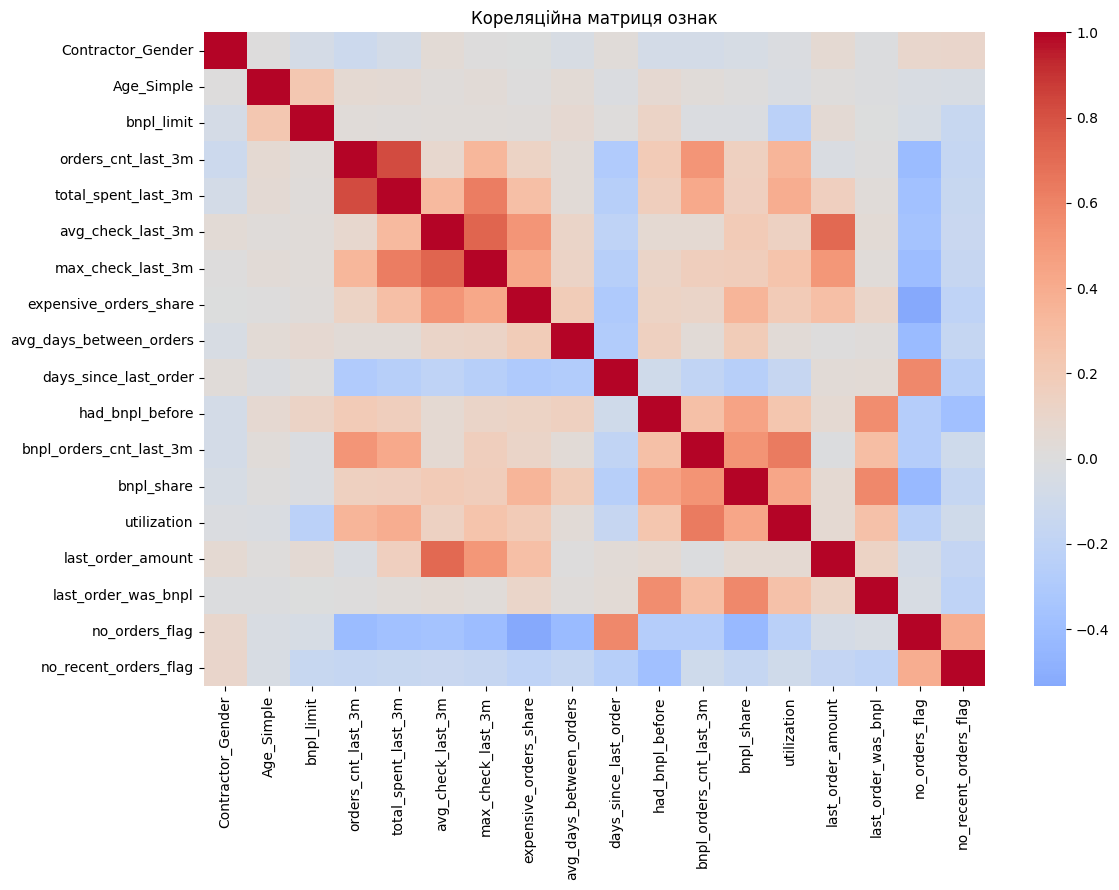

In [3]:
plt.figure(figsize=(12, 9))
sns.heatmap(corr_matrix, cmap='coolwarm', center=0, annot=False)
plt.title('Кореляційна матриця ознак')
plt.tight_layout()
plt.show()

Дендрограма ієрархічної кластеризації ознак

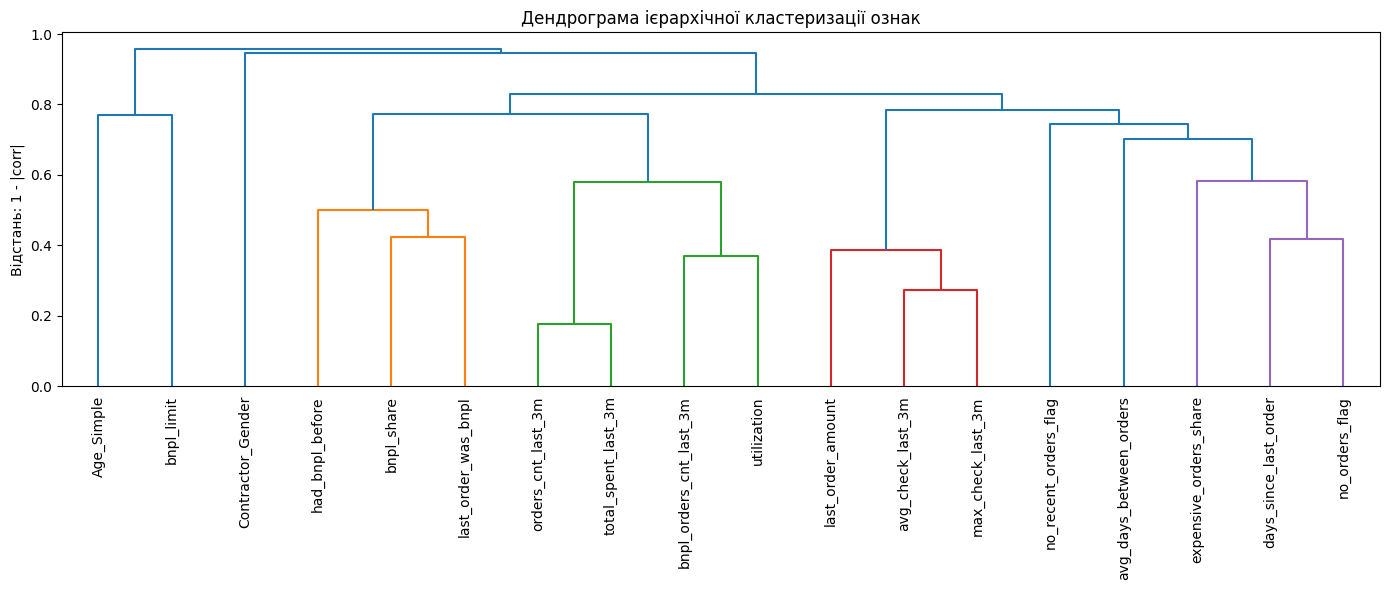

In [4]:
# матриця відстаней на основі кореляції
dist_matrix = 1 - np.abs(corr_matrix)

# condensed matrix для scipy
dist_condensed = squareform(dist_matrix.values, checks=False)

# ієрархічна кластеризація
Z = linkage(dist_condensed, method='average')

# дендрограма
plt.figure(figsize=(14, 6))
dendrogram(
    Z,
    labels=feature_cols,
    leaf_rotation=90,
    leaf_font_size=10
)
plt.title('Дендрограма ієрархічної кластеризації ознак')
plt.ylabel('Відстань: 1 - |corr|')
plt.tight_layout()
plt.show()

Виділити кластери ознак таблицею. Беру 4 кластери і дивлюсь склад.

In [5]:
clusters = fcluster(Z, t=4, criterion='maxclust')

cluster_table = pd.DataFrame({
    'feature': feature_cols,
    'cluster': clusters
}).sort_values(['cluster', 'feature'])

cluster_table

,feature,cluster
1,Age_Simple,1
2,bnpl_limit,1
11,bnpl_orders_cnt_last_3m,2
12,bnpl_share,2
10,had_bnpl_before,2
15,last_order_was_bnpl,2
3,orders_cnt_last_3m,2
4,total_spent_last_3m,2
13,utilization,2
5,avg_check_last_3m,3


Зручний вивід по кластерах

In [6]:
cluster_groups = cluster_table.groupby('cluster')['feature'].apply(list).reset_index()
cluster_groups

,cluster,feature
0,1,"[Age_Simple, bnpl_limit]"
1,2,"[bnpl_orders_cnt_last_3m, bnpl_share, had_bnpl..."
2,3,"[avg_check_last_3m, avg_days_between_orders, d..."
3,4,[Contractor_Gender]
